In [14]:
import numpy as np
import matplotlib.pyplot as plt
import psana
from psana import MPIDataSource, Detector
import h5py as h5

In [15]:
run_num = 475 # Q cal 475
# Define parameters
exp_name = 'xppl1016922'
smalldata_path = '/sdf/data/lcls/ds/xpp/{}/hdf5/smalldata/'.format(exp_name)

# Load the intensity
Filter based on ipm2

In [16]:
# Load the result from droplet analysis
with h5.File(smalldata_path + '{}_Run{:04d}.h5'.format(exp_name, run_num),'r') as f:
    ebeam = np.array(f['ebeam']['photon_energy'])
    sample_diode = f['diodeU']['channels'][:,1]
    cc = np.array(f['ai/ch03']) # shutter > 4 means open
    vcc = np.array(f['ai/ch02']) # shutter > 4 means open
    ipm2 = np.array(f['ipm2/sum'])  # intensity  # use this for filtering, upstream intensity
    d1 = np.array(f['diode2/channels'][:,0]) # intensity
    d5 = np.array(f['diodeU/channels'][:,3])# intensity
    d6 = np.array(f['lombpm/channels'][:,2])# intensity


# Keep only the first 1% of data

In [17]:
# threshold for top 1% highest values
thr_high = np.percentile(ipm2, 99)

# indices excluding top 1%
mask_ipm2 = np.where(ipm2 < thr_high)[0]

In [18]:

ds = MPIDataSource('exp=xppl1016922:run={}:smd'.format(run_num))
detname = 'jungfrau1M_alcove'
det = Detector(detname) 
nimg = 100 # max
img_num = 0
imgs = []
sumimg=np.zeros((1064,1030))
for nevt,evt in enumerate(ds.events()):
    #if nevt == nimg: break
    #i0s[nevt] = det_i0.get(evt).TotalIntensity()
    tmp=[]
    if nevt in mask_ipm2:
        img = det.image(evt)
        imgs.append(np.copy(img))
        tmp=np.copy(img)
        tmp[tmp<0]=0
        sumimg = sumimg + tmp
        img_num += 1
    if img_num == nimg: break
s = 'r' +str(run_num) +'data= sumimg'


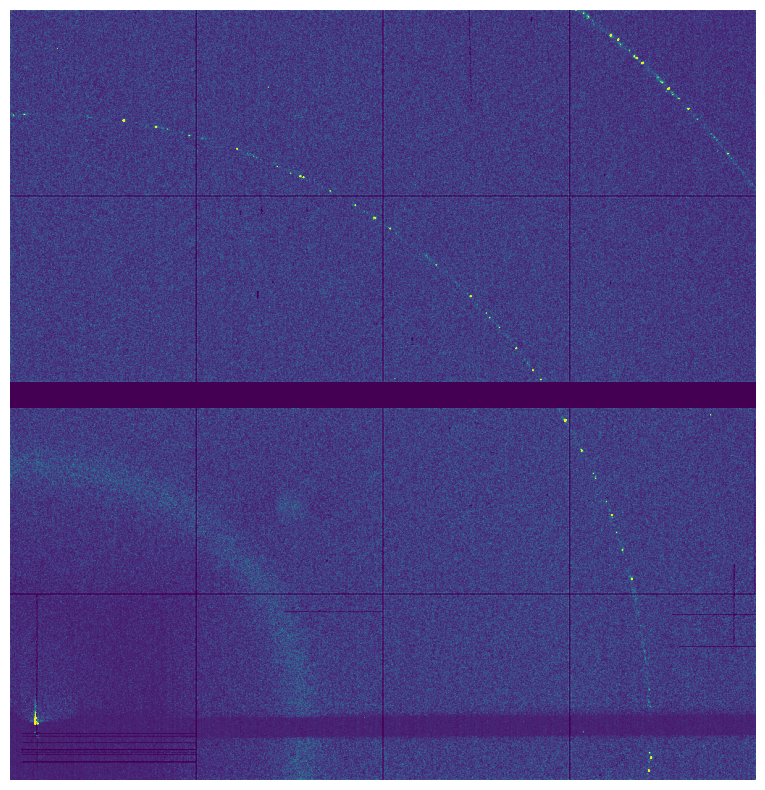

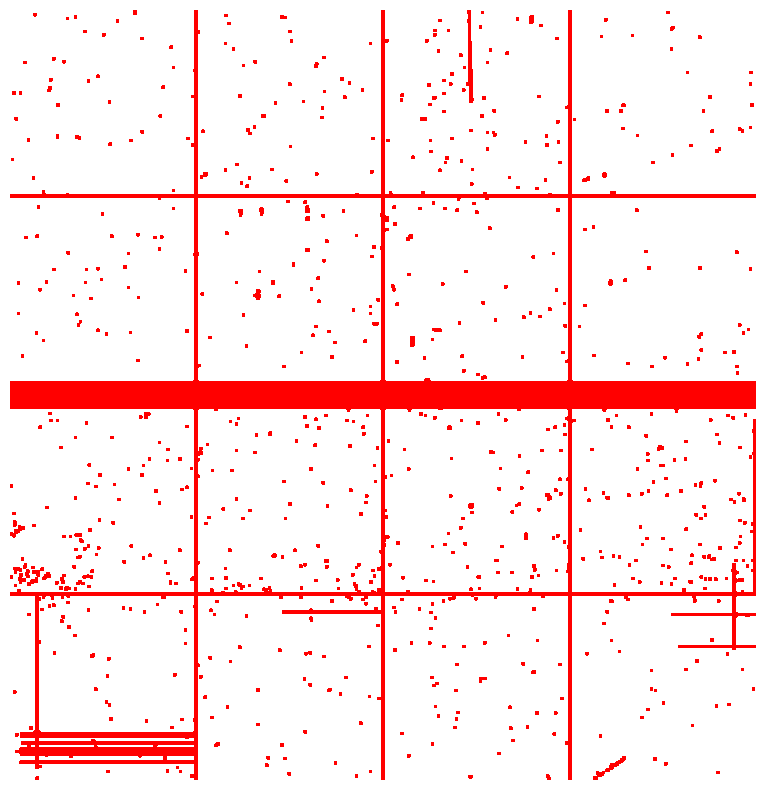

In [19]:
import matplotlib.colors as mcolors
from scipy.ndimage import binary_dilation

plt.figure(figsize=(10,10));plt.imshow(sumimg,vmin=1.5,vmax=100)
plt.axis('off')
plt.savefig('lab6.png',bbox_inches='tight', pad_inches=0)

# Create zeroMask
zeroMask = sumimg <= 0

# Extend True values to neighboring pixels
structure = np.ones((5, 5))  # Define a 3x3 structure for dilation
zeroMask_extended = binary_dilation(zeroMask, structure=structure)



# Create a custom colormap: red for True, white for False
colors = ['white', 'red']
cmap = mcolors.ListedColormap(colors)

# Display and save the second image (zeroMask with custom colormap)
plt.figure(figsize=(10,10))
plt.imshow(zeroMask_extended, cmap=cmap)
plt.axis('off')
plt.savefig('lab6_zeroMask.png', bbox_inches='tight', pad_inches=0)
plt.show()

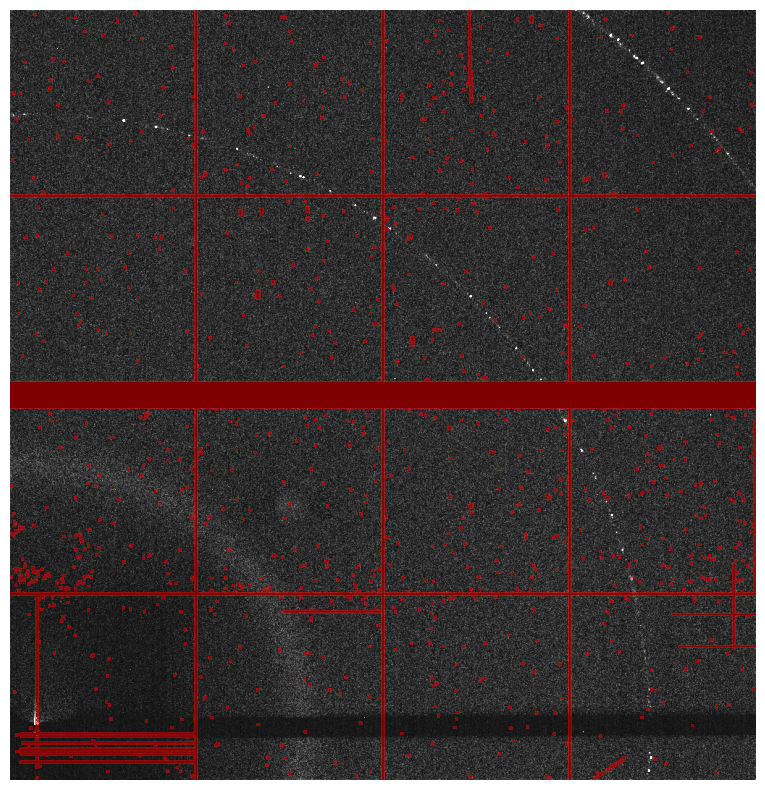

In [20]:
# Create a custom colormap: red for True, transparent for False
colors = [(1, 1, 1, 0), (1, 0, 0, 1)]  # White (fully transparent) and red
cmap = mcolors.ListedColormap(colors)

# Display and save the overlapped images
plt.figure(figsize=(10,10))
plt.imshow(sumimg, vmin=1.5, vmax=100, cmap='gray')
plt.imshow(zeroMask_extended, cmap=cmap, alpha=0.5)
plt.axis('off')
plt.savefig('lab6_overlapped.png', bbox_inches='tight', pad_inches=0)
plt.show()

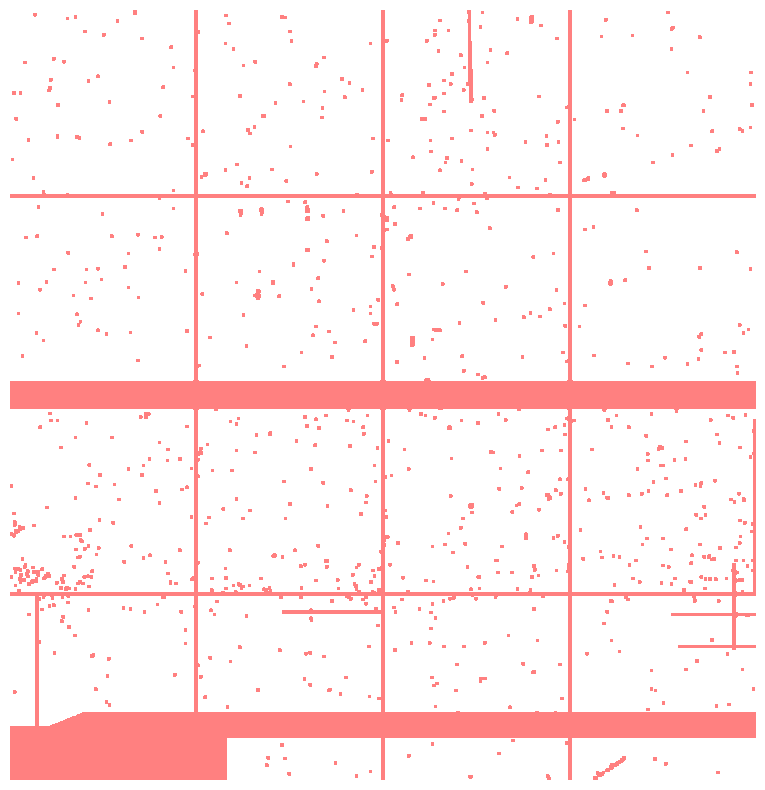

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon
from matplotlib.path import Path


## Convert the list of images to a 3D numpy array
#images_stack = np.stack(imgs, axis=-1)
#
## Calculate the mean and standard deviation for each pixel
#mean_img = np.mean(images_stack, axis=-1)
#std_img = np.std(images_stack, axis=-1)
#
## Calculate the threshold for each pixel
#threshold = std_img / mean_img

# Create the threshold mask
thresholdMask = np.zeros_like(img,dtype=bool)
thresholdMask[970:1006,100:1064] = True
thresholdMask[1000:,0:300] = True
thresholdMask[990:1000,0:100] = True


# Create a triangle mask
triangle = np.zeros_like(thresholdMask)
triangle_vertices = [(970, 100), (990, 100), (990, 50)]
rr, cc = np.meshgrid(np.arange(triangle.shape[0]), np.arange(triangle.shape[1]), indexing='ij')
path = Path(triangle_vertices)
triangle = path.contains_points(np.hstack((rr.flatten()[:, np.newaxis], cc.flatten()[:, np.newaxis])))
triangle = triangle.reshape(thresholdMask.shape)

# Combine the triangle mask with the threshold mask
thresholdMask |= triangle
TotalMask = thresholdMask | zeroMask_extended

# Create a custom colormap: red for True, transparent for False
colors = [(1, 1, 1, 0), (1, 0, 0, 1)]  # White (fully transparent) and red
cmap = mcolors.ListedColormap(colors)

plt.figure(figsize=(10, 10))
plt.imshow(TotalMask, cmap=cmap, alpha=0.5)
plt.axis('off')
plt.show()


np.save('Mask.npy', TotalMask)



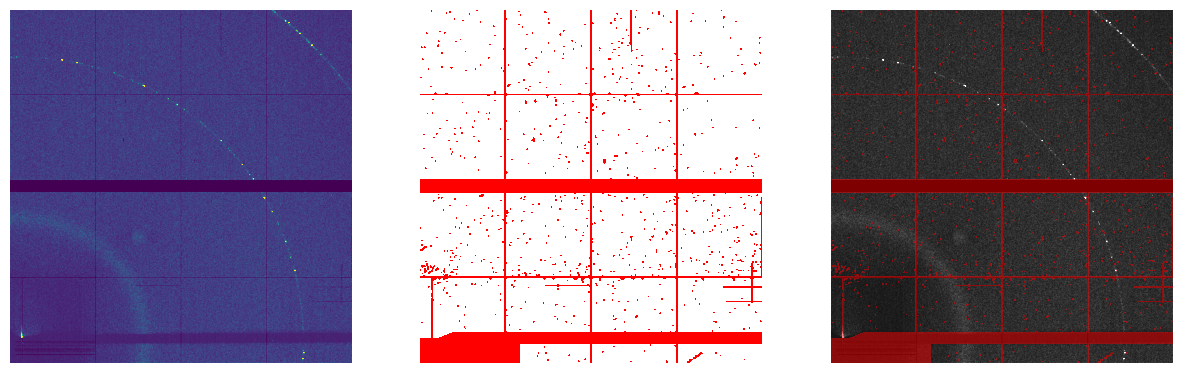

In [22]:
import matplotlib.colors as mcolors
from scipy.ndimage import binary_dilation

plt.figure(figsize=[15,50]);
plt.subplot(1,3,1)
plt.imshow(sumimg,vmin=1.5,vmax=100)
plt.axis('off')
#plt.savefig('lab6.png',bbox_inches='tight', pad_inches=0)


# Create a custom colormap: red for True, white for False
colors = ['white', 'red']
cmap = mcolors.ListedColormap(colors)

# Display and save the second image (zeroMask with custom colormap)
plt.subplot(1,3,2)
plt.imshow(TotalMask, cmap=cmap)
plt.axis('off')

# Create a custom colormap: red for True, transparent for False
colors = [(1, 1, 1, 0), (1, 0, 0, 1)]  # White (fully transparent) and red
cmap = mcolors.ListedColormap(colors)

# Display and save the overlapped images
plt.subplot(1,3,3)
plt.imshow(sumimg, vmin=1.5, vmax=100, cmap='gray')
plt.imshow(TotalMask, cmap=cmap, alpha=0.5)
plt.axis('off')

plt.savefig('lab6_overlapped.png', bbox_inches='tight', pad_inches=0)

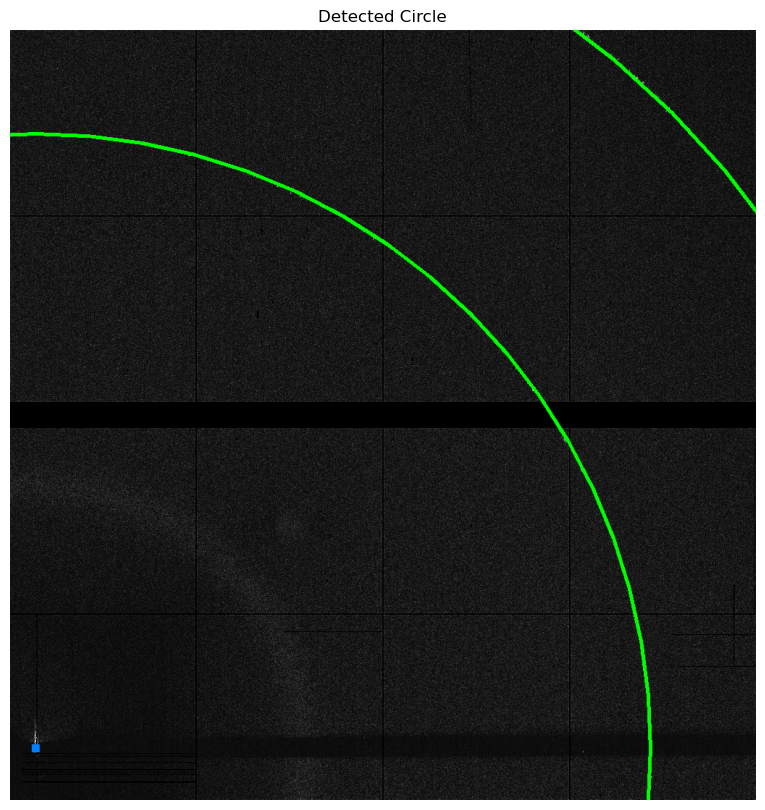

In [23]:
import cv2
plt.figure(figsize=[10,10])

# Convert image data to uint8 for circle detection
image_uint8 = (sumimg / 200 * 255).astype(np.uint8)

# Assuming image_uint8 is your input image and circles contains the circle data
# If you only have one circle, you should define it as a list of lists
x=35
y=992
r=849
circles = np.array([[x,y, r],[x, y, r*2.1359/1.51148927*1.035]])

# Ensure at least some circles are found
if circles is not None:
    circles = np.round(circles).astype("int")

    # Convert the image to color for drawing purposes
    output = cv2.cvtColor(image_uint8, cv2.COLOR_GRAY2BGR)

    # Draw the first detected circle
    for circle in circles:
        x, y, r = circle
        # Draw the circle in the output image
        cv2.circle(output, (x, y), r, (0, 255, 0), 4)
        cv2.rectangle(output, (x - 5, y - 5), (x + 5, y + 5), (0, 128, 255), -1)

        plt.imshow(output)
        plt.title('Detected Circle')
        plt.axis('off')

else:
    print("No circles were found")

plt.savefig('center.png')

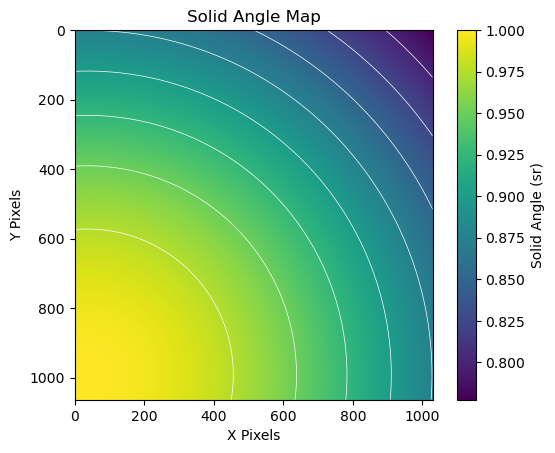

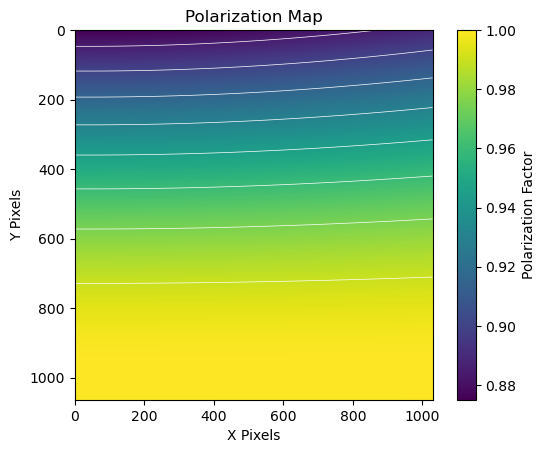

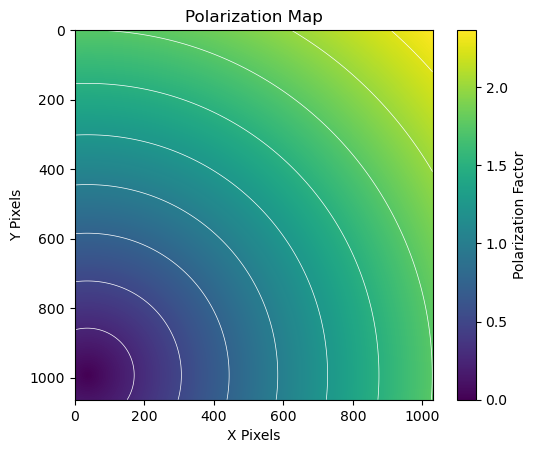

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Define constants
p_vector = np.array([0, 1, 0])
centerX = 35
centerY = 992
pixel_size = 75e-6
detector_distance = 0.1969
E = 9.6  # (keV)
wave_length = 12.398 / E
cols = 1030
rows = 1064

# Generate meshgrid for pixel coordinates
X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
distances_map = np.sqrt((X - centerX) ** 2 + (Y - centerY) ** 2) * pixel_size
theta_map = np.arctan(distances_map / detector_distance)
q_map = 4 * np.pi * np.sin(theta_map / 2) / wave_length
solid_angle_map = (pixel_size * pixel_size) / np.square(detector_distance / np.cos(theta_map))
solid_angle_map = solid_angle_map/solid_angle_map[centerY,centerX]


# Scattering vector for each pixel
x = (np.arange(cols) - centerX) * pixel_size
y = (np.arange(rows) - centerY) * pixel_size
x, y = np.meshgrid(x, y)
z = detector_distance * np.ones_like(x)
np_vectors = np.stack((x, y, z), axis=-1)

# Polarization factor
p_vector_unit = p_vector / np.linalg.norm(p_vector)
np_vectors_unit = np_vectors / np.linalg.norm(np_vectors, axis=-1)[..., np.newaxis]
polarization_map = 1 - np.square(np.dot(np_vectors_unit, p_vector_unit))


# Display the solid angle map with contours
plt.figure()
plt.imshow(solid_angle_map)
plt.colorbar(label='Solid Angle (sr)')
plt.contour(solid_angle_map, levels=10, colors='white', linewidths=0.5, origin='lower')
plt.title('Solid Angle Map')
plt.xlabel('X Pixels')
plt.ylabel('Y Pixels')
plt.show()

# Display the polarization map with contours
plt.figure()
plt.imshow(polarization_map)
plt.colorbar(label='Polarization Factor')
plt.contour(polarization_map, levels=10, colors='white', linewidths=0.5, origin='lower')
plt.title('Polarization Map')
plt.xlabel('X Pixels')
plt.ylabel('Y Pixels')
plt.show()

plt.figure()
plt.imshow(q_map)
plt.colorbar(label='Polarization Factor')
plt.contour(q_map, levels=10, colors='white', linewidths=0.5, origin='lower')
plt.title('Polarization Map')
plt.xlabel('X Pixels')
plt.ylabel('Y Pixels')
plt.show()

np.savez(f'correction.npz',
                 polarization_map = polarization_map, 
                 solid_angle_map = solid_angle_map)



In [25]:
def Y_getQmap(shape, center, E = 10, L = 0.13, pixelsize = 50e-6):
    lam = 12.398/E
    k = 2*np.pi/lam
    det_angle = np.deg2rad(0)
    y, x = np.indices(shape)
    x = x - center[0]
    y = y - center[1]
    ll = np.sqrt((pixelsize*x*np.cos(det_angle))**2+(pixelsize*y)**2+(L-x*pixelsize*np.sin(det_angle))**2)
    tth = np.arccos((L-x*pixelsize*np.sin(det_angle))/ll)
    qmap = 2*k*np.sin(tth/2.)
    
    return qmap

In [26]:
qmap = Y_getQmap(shape=sumimg.shape,center=[35,992],E=9.6,L=0.1969,pixelsize=75e-6)
np.save('qmap.npy', qmap)

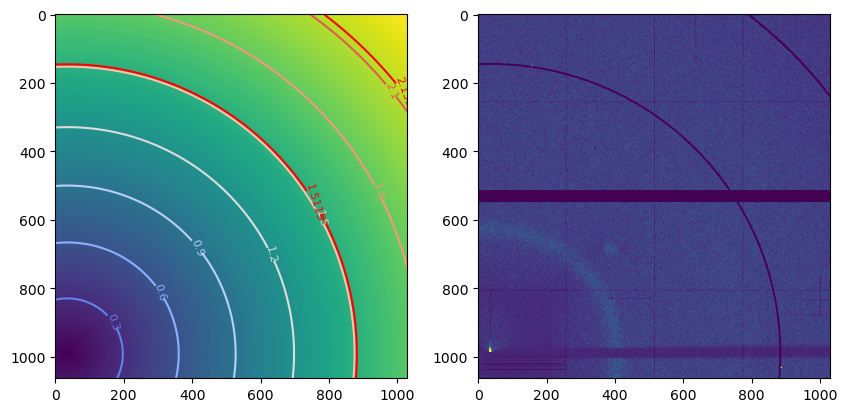

In [27]:
sample=sumimg
plt.figure(figsize=(10,10))

# First subplot
plt.subplot(1, 2, 1)
plt.imshow(qmap)
contours = plt.contour(qmap, cmap='coolwarm')  # using 'coolwarm' for blue to red
plt.clabel(contours, inline=True, fontsize=8)
#plt.colorbar()

contours = plt.contour(qmap, levels=[1.51148, 2.1359], colors='red')
plt.clabel(contours, inline=True, fontsize=8)






qind1= np.where((qmap >= 1.51148-0.005) & (qmap < 1.51148+0.005))
qind2= np.where((qmap >= 2.1359 - 0.005) & (qmap < 2.1359+0.005))

sample[qind1]=0
sample[qind2]=0
plt.subplot(1,2,2);plt.imshow(sample,vmax=100)
plt.savefig('qmap.png')